In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
import cmap



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()

In [2]:
# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"
    SLIDES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/presentation_figures"


else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


In [3]:
# load the softmax data // GAUSSIAN
softmax_payload = pickle.load(open(os.path.join(DATA_PATH, "softmax_mc_analysis_gauss_2026-08-17.pkl"), "rb"))
softmax_data = softmax_payload['data']
print(f"SOFTMAX CONFIGS: {softmax_payload['configs']}")
softmax_data = pd.DataFrame(softmax_data)
softmax_data["sf_opt"] = softmax_data["norm_ratio_z_s"]/softmax_data["norm_ratio_z_q"]
print(softmax_data.head())

# load the softmax-jacobian data
softmax_jac_payload = pickle.load(open(os.path.join(DATA_PATH, "softmax_jacobian_mc_analysis_gauss_2026-08-17.pkl"), "rb"))
softmax_jac_data = softmax_jac_payload['data']
print(f"SOFTMAX JACOBIAN CONFIGS: {softmax_jac_payload['configs']}")

softmax_jac_data = pd.DataFrame(softmax_jac_data)
softmax_jac_data["sf_opt"] = softmax_jac_data["scale_factor"]*(1/softmax_jac_data["norm_ratio_z_q"])
print(softmax_jac_data.head())


# Loading data // Logistic
softmax_log_payload = pickle.load(open(os.path.join(DATA_PATH, "softmax_mc_analysis_logistic_2026-08-29.pkl"), "rb"))
softmax_log_data = softmax_log_payload["data"]
print(f"SOFTMAX LOG CONFIGS: {softmax_log_payload["configs"]}")
softmax_log_data = pd.DataFrame(softmax_log_data)

softmax_log_jac_payload = pickle.load(open(os.path.join(DATA_PATH, "softmax_jacobian_mc_analysis_logistic_2026-08-29.pkl"), "rb"))
softmax_log_jac_data = softmax_log_jac_payload["data"]
print(f"SOFTMAX LOG CONFIGS: {softmax_log_jac_payload["configs"]}")
softmax_log_jac_data = pd.DataFrame(softmax_log_jac_data)

print(f"SOFTMAX LOGISTIC: \n {softmax_log_data.head()}")
print(f"SOFTMAX LOGISTIC JACOBIAN: \n {softmax_log_jac_data.head()}")



SOFTMAX CONFIGS: {'resamples': 30, 'num_classes': [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], 'preact_scale': 1.0, 'noise_scale': 1.0}
   cos_sim_z_s  cos_sim_z_q  cos_sim_q_s  norm_ratio_z_s  norm_ratio_z_q  \
0     0.923279     0.939999     0.998938        1.307410        1.281176   
1     0.997372     0.999651     0.998938        1.033598        1.012859   
2     0.968323     0.978801     0.998938        1.155598        1.132411   
3     0.968323     0.978801     0.998938        1.155598        1.132411   
4     0.977789     0.986409     0.998938        1.121882        1.099372   

   num_classes  int_window  resample    sf_opt  
0            2           2         0  1.020476  
1            2           4         0  1.020476  
2            2           8         0  1.020476  
3            2          16         0  1.020476  
4            2          32         0  1.020476  
SOFTMAX JACOBIAN CONFIGS: {'resamples': 30, 'num_classes': [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], 'preact_sca

In [4]:
print(softmax_log_data["int_window"].unique())
print(softmax_log_jac_data["int_window"].unique())

[    2     6    18    58   180   555  1709  5268 16229 49999]
[    2     6    18    58   180   555  1709  5268 16229 49999]


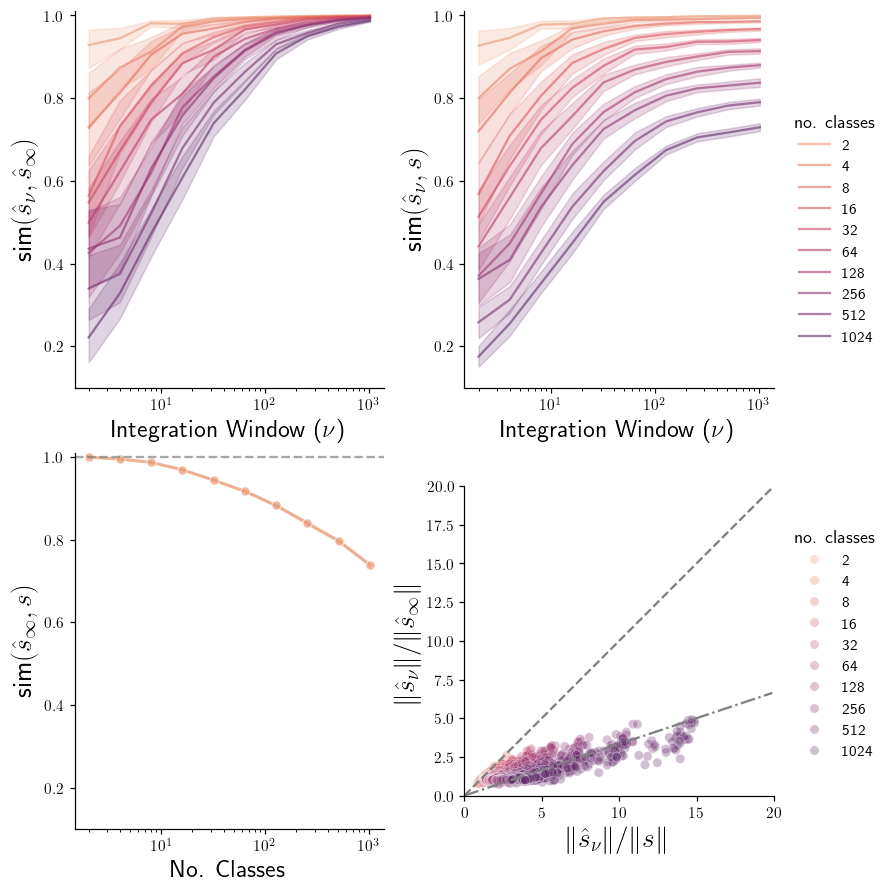

In [ ]:
## constructing the guides
x = jnp.arange(0, 20, 0.1)

# plotting softmax data
fig, ax = plt.subplots(2, 2, figsize=(8, 8), dpi=110, layout="constrained")

# for axs in ax.ravel():
#     axs.set_xscale("log", base=2)

flare_pal = sns.color_palette("flare", len(softmax_data['num_classes'].unique()))
crest_pal = sns.color_palette("crest", len(softmax_data['num_classes'].unique()))
cb_pal = sns.color_palette("colorblind", len(softmax_data['num_classes'].unique()))

## z and q
sns.lineplot(data=softmax_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0,0], palette=flare_pal)
ax[0, 0].set_xscale("log", base=10) 
ax[0,0].set_ylabel(r"$\text{sim}(\hat{s}_\nu, \hat{s}_\infty)$", fontsize=18)
ax[0,0].legend().set_visible(False)

## z and s
sns.lineplot(data=softmax_data, x="int_window", y="cos_sim_z_s", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0,1], palette=flare_pal)
ax[0, 1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[0, 1].set_ylabel(r"$\text{sim}(\hat{s}_\nu, s)$", fontsize=18)
ax[0, 1].set_xscale("log", base=10)

for axs in [ax[0,0], ax[0, 1]]:
    axs.set_xlabel(r"Integration Window ($\nu$)", fontsize=16)

## norm comparison: z vs s
sns.scatterplot(data=softmax_data, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=flare_pal, ax=ax[1, 1], alpha=0.3)
ax[1, 1].set_ylabel(r"$\lVert \hat{s}_\nu \rVert / \lVert \hat{s}_\infty \rVert$", fontsize=18)
ax[1, 1].set_xlabel(r"$\lVert \hat{s}_\nu \rVert / \lVert s \rVert$", fontsize=18)
ax[1, 1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[1, 1].plot(x, x, color="0.5", lw=1.5, ls="--")
ax[1, 1].plot(x, x/3, color="0.5", lw=1.5, ls="-.")
ax[1, 1].set_aspect("equal")
ax[1, 1].set_xlim(0, 20)
ax[1, 1].set_ylim(0, 20)

## cosine sim q vs num classes
sns.lineplot(data=softmax_data, x="num_classes", y="cos_sim_q_s", ax=ax[1, 0], alpha=0.7, color=flare_pal[0], lw=2, marker="o")
ax[1, 0].set_xscale("log", base=10)
ax[1, 0].axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
ax[1, 0].set_ylabel(r"$\text{sim}(\hat{s}_\infty, s)$", fontsize=18)
ax[1, 0].set_xlabel("No. Classes", fontsize=16)

for axs in [ax[0,0], ax[0,1], ax[1,0]]:
    axs.set_ylim(0.1, 1.01)
sns.despine()
# plt.tight_layout()

softmax_gauss_fn = f"softmax_gauss_mc_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, softmax_gauss_fn), transparent=True, dpi=300, bbox_inches="tight")

<>:23: SyntaxWarning: invalid escape sequence '\#'
<>:23: SyntaxWarning: invalid escape sequence '\#'
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_49439/3812811751.py:23: SyntaxWarning: invalid escape sequence '\#'
  axl_inset.set_xlabel("\# Classes", fontsize=14)


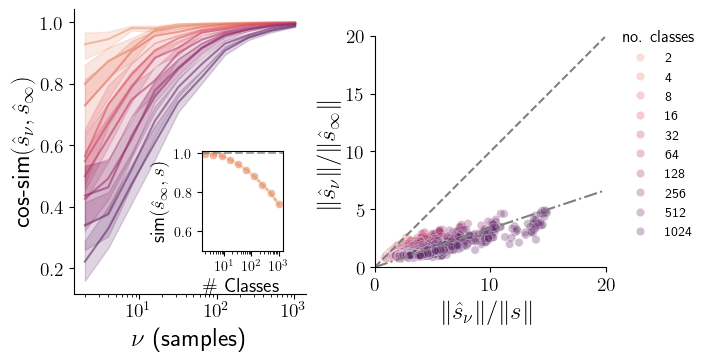

In [65]:
# modifying the above figure: bottom left plot as inset in top left, remove top right, move bottom right to top right
flare_pal = sns.color_palette("flare", len(softmax_data['num_classes'].unique()))
crest_pal = sns.color_palette("crest", len(softmax_data['num_classes'].unique()))
cb_pal = sns.color_palette("colorblind", len(softmax_data['num_classes'].unique()))

# for guides
x = jnp.arange(0, 20, 0.1)

fig, ax = plt.subplots(1, 2, figsize=(7, 3.5), layout="constrained")

sns.lineplot(data=softmax_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0], palette=flare_pal)
ax[0].set_xscale("log", base=10) 
ax[0].set_ylabel(r"$\text{cos-sim}(\hat{s}_\nu, \hat{s}_\infty)$", fontsize=18)
ax[0].legend().set_visible(False)
ax[0].set_xlabel(r"$\nu$ (samples)", fontsize=18)

# add the inset axis
axl_inset = ax[0].inset_axes([0.55, 0.15, 0.35, 0.35])
sns.lineplot(data=softmax_data, x="num_classes", y="cos_sim_q_s", ax=axl_inset, alpha=0.7, color=flare_pal[0], lw=2, marker="o")
axl_inset.set_xscale("log", base=10)
axl_inset.axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
axl_inset.set_ylabel(r"$\text{sim}(\hat{s}_\infty, s)$", fontsize=14)
axl_inset.set_xlabel("\# Classes", fontsize=14)
axl_inset.set_ylim(0.5, 1.01)
# sns.despine(ax=axl_inset)

## norm comparison: z vs s
sns.scatterplot(data=softmax_data, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=flare_pal, ax=ax[1], alpha=0.3)
ax[1].set_ylabel(r"$\lVert \hat{s}_\nu \rVert / \lVert \hat{s}_\infty \rVert$", fontsize=18)
ax[1].set_xlabel(r"$\lVert \hat{s}_\nu \rVert / \lVert s \rVert$", fontsize=18)
ax[1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[1].plot(x, x, color="0.5", lw=1.5, ls="--")
ax[1].plot(x, x/3, color="0.5", lw=1.5, ls="-.")
ax[1].set_aspect("equal")
ax[1].set_xlim(0, 20)
ax[1].set_ylim(0, 20)

for axs in [ax[0], ax[1]]:
    axs.tick_params(axis='both', which='major', labelsize=14)
    

sns.despine()

# softmax_gauss_fn2 = f"softmax_gauss_mc_{today}.png"
# fig.savefig(os.path.join(FIGURES_PATH, softmax_gauss_fn2), transparent=True, dpi=300, bbox_inches="tight")

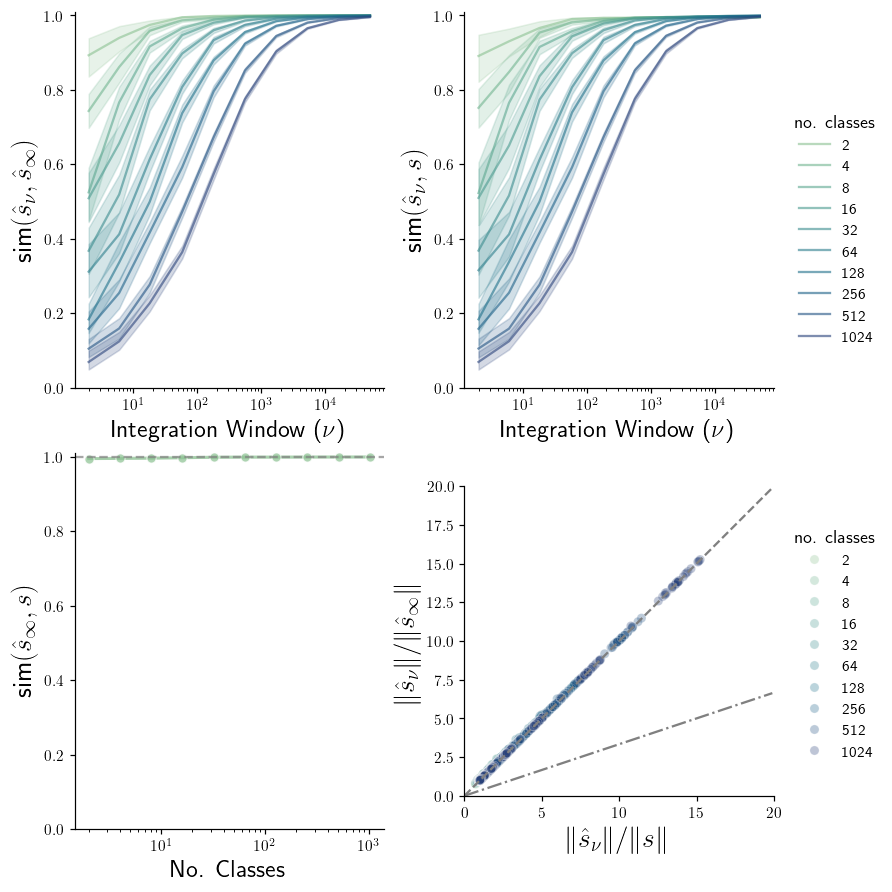

In [ ]:
# plotting the LOGISTIC NOISE
## constructing the guides
x = jnp.arange(0, 20, 0.1)

# plotting softmax data
fig, ax = plt.subplots(2, 2, figsize=(8, 8), dpi=110, layout="constrained")

# for axs in ax.ravel():
#     axs.set_xscale("log", base=2)

flare_pal = sns.color_palette("flare", len(softmax_log_data['num_classes'].unique()))
crest_pal = sns.color_palette("crest", len(softmax_log_data['num_classes'].unique()))
cb_pal = sns.color_palette("colorblind", len(softmax_log_data['num_classes'].unique()))

## z and q
sns.lineplot(data=softmax_log_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0,0], palette=crest_pal)
ax[0, 0].set_xscale("log", base=10) 
ax[0,0].set_ylabel(r"$\text{sim}(\hat{s}_\nu, \hat{s}_\infty)$", fontsize=18)
ax[0,0].legend().set_visible(False)

## z and s
sns.lineplot(data=softmax_log_data, x="int_window", y="cos_sim_z_s", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0,1], palette=crest_pal)
ax[0, 1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[0, 1].set_ylabel(r"$\text{sim}(\hat{s}_\nu, s)$", fontsize=18)
ax[0, 1].set_xscale("log", base=10)

for axs in [ax[0,0], ax[0, 1]]:
    axs.set_xlabel(r"Integration Window ($\nu$)", fontsize=16)

## norm comparison: z vs s
sns.scatterplot(data=softmax_log_data, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=crest_pal, ax=ax[1, 1], alpha=0.3)
ax[1, 1].set_ylabel(r"$\lVert \hat{s}_\nu \rVert / \lVert \hat{s}_\infty \rVert$", fontsize=18)
ax[1, 1].set_xlabel(r"$\lVert \hat{s}_\nu \rVert / \lVert s \rVert$", fontsize=18)
ax[1, 1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[1, 1].plot(x, x, color="0.5", lw=1.5, ls="--")
ax[1, 1].plot(x, x/3, color="0.5", lw=1.5, ls="-.")
ax[1, 1].set_aspect("equal")
ax[1, 1].set_xlim(0, 20)
ax[1, 1].set_ylim(0, 20)

## cosine sim q vs num classes
sns.lineplot(data=softmax_log_data, x="num_classes", y="cos_sim_q_s", ax=ax[1, 0], alpha=0.7, color=crest_pal[0], lw=2, marker="o")
ax[1, 0].set_xscale("log", base=10)
ax[1, 0].axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
ax[1, 0].set_ylabel(r"$\text{sim}(\hat{s}_\infty, s)$", fontsize=18)
ax[1, 0].set_xlabel("No. Classes", fontsize=16)

for axs in [ax[0,0], ax[0,1], ax[1,0]]:
    axs.set_ylim(0.0, 1.01)
sns.despine()
# plt.tight_lay


softmax_log_fn = f"softmax_log_mc_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, softmax_log_fn), transparent=True, dpi=300, bbox_inches="tight")

<>:23: SyntaxWarning: invalid escape sequence '\#'
<>:23: SyntaxWarning: invalid escape sequence '\#'
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_49439/1103763156.py:23: SyntaxWarning: invalid escape sequence '\#'
  axl_inset.set_xlabel("\# Classes", fontsize=14)


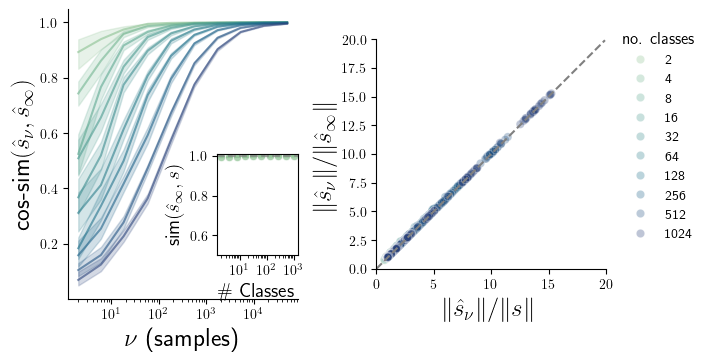

In [ ]:
# modifying the above figure: bottom left plot as inset in top left, remove top right, move bottom right to top right
flare_pal = sns.color_palette("flare", len(softmax_data['num_classes'].unique()))
crest_pal = sns.color_palette("crest", len(softmax_data['num_classes'].unique()))
cb_pal = sns.color_palette("colorblind", len(softmax_data['num_classes'].unique()))

# for guides
x = jnp.arange(0, 20, 0.1)

fig, ax = plt.subplots(1, 2, figsize=(7, 3.5), layout="constrained")

sns.lineplot(data=softmax_log_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0], palette=crest_pal)
ax[0].set_xscale("log", base=10) 
ax[0].set_ylabel(r"$\text{cos-sim}(\hat{s}_\nu, \hat{s}_\infty)$", fontsize=18)
ax[0].legend().set_visible(False)
ax[0].set_xlabel(r"$\nu$ (samples)", fontsize=18)

# add the inset axis
axl_inset = ax[0].inset_axes([0.65, 0.15, 0.35, 0.35])
sns.lineplot(data=softmax_log_data, x="num_classes", y="cos_sim_q_s", ax=axl_inset, alpha=0.7, color=crest_pal[0], lw=2, marker="o")
axl_inset.set_xscale("log", base=10)
axl_inset.axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
axl_inset.set_ylabel(r"$\text{sim}(\hat{s}_\infty, s)$", fontsize=14)
axl_inset.set_xlabel("\# Classes", fontsize=14)
axl_inset.set_ylim(0.5, 1.01)
# sns.despine(ax=axl_inset)

## norm comparison: z vs s
sns.scatterplot(data=softmax_log_data, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=crest_pal, ax=ax[1], alpha=0.3)
ax[1].set_ylabel(r"$\lVert \hat{s}_\nu \rVert / \lVert \hat{s}_\infty \rVert$", fontsize=18)
ax[1].set_xlabel(r"$\lVert \hat{s}_\nu \rVert / \lVert s \rVert$", fontsize=18)
ax[1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[1].plot(x, x, color="0.5", lw=1.5, ls="--")
# ax[1].plot(x, x/3, color="0.5", lw=1.5, ls="-.")
ax[1].set_aspect("equal")
ax[1].set_xlim(0, 20)
ax[1].set_ylim(0, 20)

sns.despine()

# softmax_log_fn2 = f"softmax_log_mc_{today}.png"
# fig.savefig(os.path.join(FIGURES_PATH, softmax_log_fn2), transparent=True, dpi=300, bbox_inches="tight")

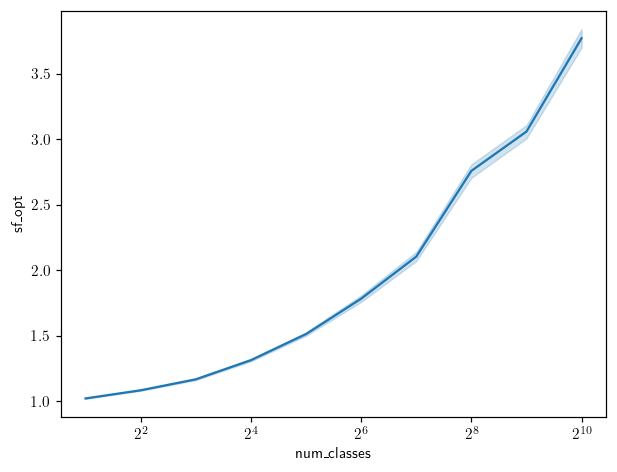

In [104]:
fig, ax = plt.subplots(dpi=110)
sns.lineplot(data=softmax_data, x="num_classes", y="sf_opt")

ax.set_xscale("log", base=2)

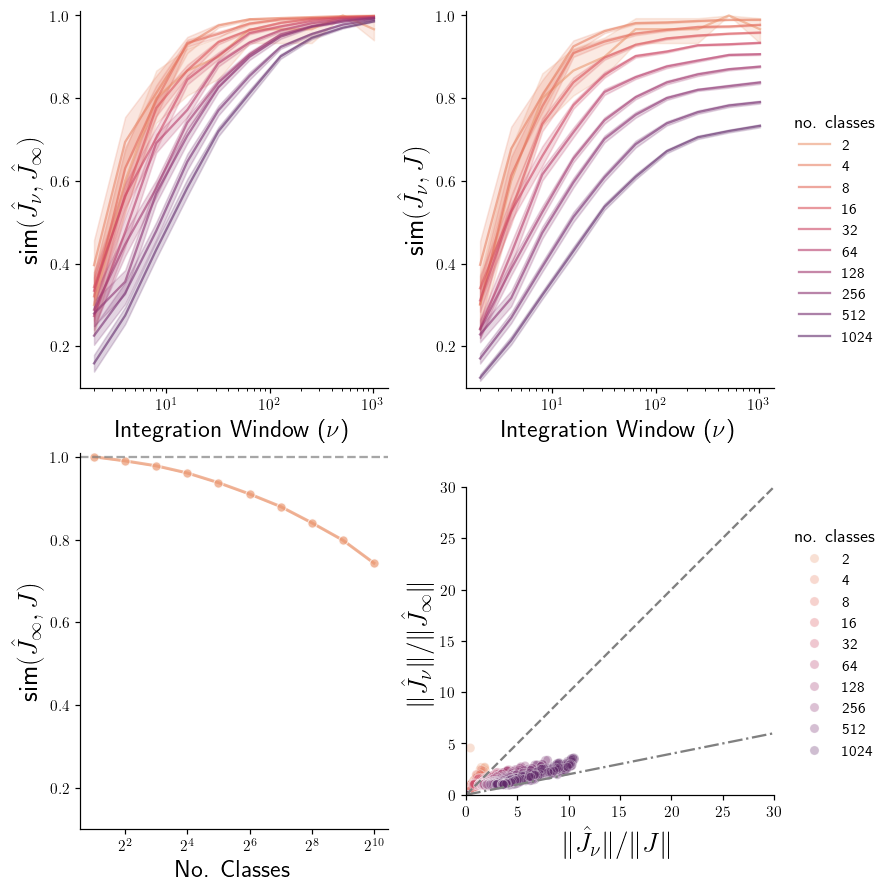

In [ ]:
# plotting softmax jacobian: GAUSSIAN NOISE
fig, ax = plt.subplots(2, 2, figsize=(8, 8), dpi=110, layout="constrained")

x = jnp.arange(0, 30, 0.1)
# for axs in ax.ravel():
#     axs.set_xscale("log", base=2)

flare_pal = sns.color_palette("flare", len(softmax_data['num_classes'].unique()))
crest_pal = sns.color_palette("crest", len(softmax_data['num_classes'].unique()))
cb_pal = sns.color_palette("colorblind", len(softmax_data['num_classes'].unique()))

## z and q
sns.lineplot(data=softmax_jac_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0,0], palette=flare_pal)
ax[0, 0].set_xscale("log", base=10)
ax[0,0].set_ylabel(r"$\text{sim}(\hat{J}_\nu, \hat{J}_\infty)$", fontsize=18)
ax[0,0].legend().set_visible(False)

for axs in [ax[0,0], ax[0, 1]]:
    axs.set_xlabel(r"Integration Window ($\nu$)", fontsize=16)

## z and s
sns.lineplot(data=softmax_jac_data, x="int_window", y="cos_sim_z_s", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0,1], palette=flare_pal)
ax[0, 1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[0, 1].set_ylabel(r"$\text{sim}(\hat{J}_\nu, J)$", fontsize=18)
ax[0, 1].set_xscale("log", base=10)

## cosine sim q vs num classes
sns.lineplot(data=softmax_jac_data, x="num_classes", y="cos_sim_q_s", ax=ax[1, 0], alpha=0.7, color=flare_pal[0], lw=2, marker="o")
ax[1, 0].set_xscale("log", base=2)
ax[1, 0].axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
ax[1, 0].set_ylabel(r"$\text{sim}(\hat{J}_\infty, J)$", fontsize=18)
ax[1, 0].set_xlabel("No. Classes", fontsize=16)

for axs in [ax[0,0], ax[0,1], ax[1,0]]:
    axs.set_ylim(0.1, 1.01)

## norm comparison: z vs s
dd = softmax_jac_data.loc[softmax_jac_data['scale_factor'] == 1.0]
sns.scatterplot(data=dd, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=flare_pal, ax=ax[1, 1], alpha=0.3)
ax[1, 1].set_ylabel(r"$\lVert \hat{J}_\nu \rVert / \lVert \hat{J}_\infty \rVert$", fontsize=18)
ax[1, 1].set_xlabel(r"$\lVert \hat{J}_\nu \rVert / \lVert J \rVert$", fontsize=18)
ax[1, 1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[1, 1].plot(x, x, color="0.5", lw=1.5, ls="--")
ax[1, 1].plot(x, x/5, color="0.5", lw=1.5, ls="-.")
ax[1, 1].set_aspect("equal")
ax[1, 1].set_xlim(0, 30)
ax[1, 1].set_ylim(0, 30)

sns.despine()
# plt.tight_layout()

# softmax_gauss_jac_fn = f"softmax_gauss_jac_mc_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, softmax_gauss_jac_fn), transparent=True, dpi=300, bbox_inches="tight")

<>:25: SyntaxWarning: invalid escape sequence '\#'
<>:25: SyntaxWarning: invalid escape sequence '\#'
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_49439/3299535131.py:25: SyntaxWarning: invalid escape sequence '\#'
  axl_inset.set_xlabel("\# Classes", fontsize=14)


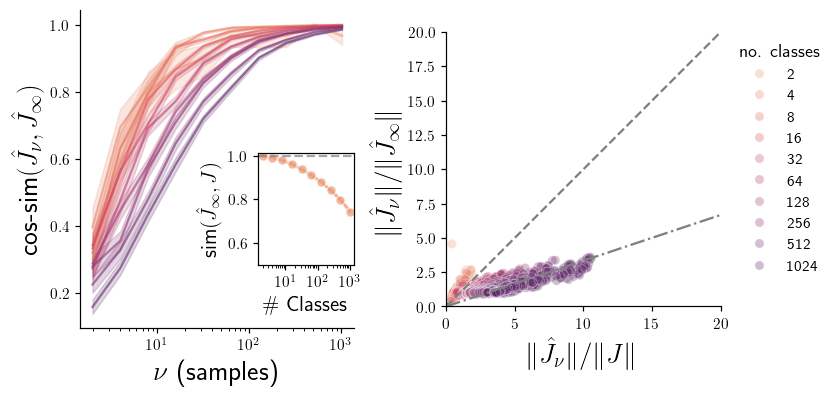

In [ ]:
# Gauss jacobian || modified figure
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.5), dpi=110, layout="constrained")

x = jnp.arange(0, 30, 0.1)
# for axs in ax.ravel():
#     axs.set_xscale("log", base=2)

flare_pal = sns.color_palette("flare", len(softmax_data['num_classes'].unique()))
crest_pal = sns.color_palette("crest", len(softmax_data['num_classes'].unique()))
cb_pal = sns.color_palette("colorblind", len(softmax_data['num_classes'].unique()))

## z and q (q vs s inset)
sns.lineplot(data=softmax_jac_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0], palette=flare_pal)
ax[0].set_xscale("log", base=10) 
ax[0].set_ylabel(r"$\text{cos-sim}(\hat{J}_\nu, \hat{J}_\infty)$", fontsize=18)
ax[0].legend().set_visible(False)
ax[0].set_xlabel(r"$\nu$ (samples)", fontsize=18)

# add the inset axis
axl_inset = ax[0].inset_axes([0.65, 0.2, 0.35, 0.35])
sns.lineplot(data=softmax_jac_data, x="num_classes", y="cos_sim_q_s", ax=axl_inset, alpha=0.7, color=flare_pal[0], lw=2, marker="o")
axl_inset.set_xscale("log", base=10)
axl_inset.axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
axl_inset.set_ylabel(r"$\text{sim}(\hat{J}_\infty, J)$", fontsize=14)
axl_inset.set_xlabel("\# Classes", fontsize=14)
axl_inset.set_ylim(0.5, 1.01)

## norm comparison: z vs s
df_c = softmax_jac_data.loc[softmax_jac_data['scale_factor'] == 1.0]
sns.scatterplot(data=df_c, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=flare_pal, ax=ax[1], alpha=0.3)
ax[1].set_ylabel(r"$\lVert \hat{J}_\nu \rVert / \lVert \hat{J}_\infty \rVert$", fontsize=18)
ax[1].set_xlabel(r"$\lVert \hat{J}_\nu \rVert / \lVert J \rVert$", fontsize=18)
ax[1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[1].plot(x, x, color="0.5", lw=1.5, ls="--")
ax[1].plot(x, x/3, color="0.5", lw=1.5, ls="-.")
ax[1].set_aspect("equal")
ax[1].set_xlim(0, 20)
ax[1].set_ylim(0, 20)



sns.despine()
# plt.tight_layout()

# softmax_gauss_jac_fn2 = f"softmax_gauss_jac_mc2_{today}.png"
# fig.savefig(os.path.join(FIGURES_PATH, softmax_gauss_jac_fn2), transparent=True, dpi=300, bbox_inches="tight")

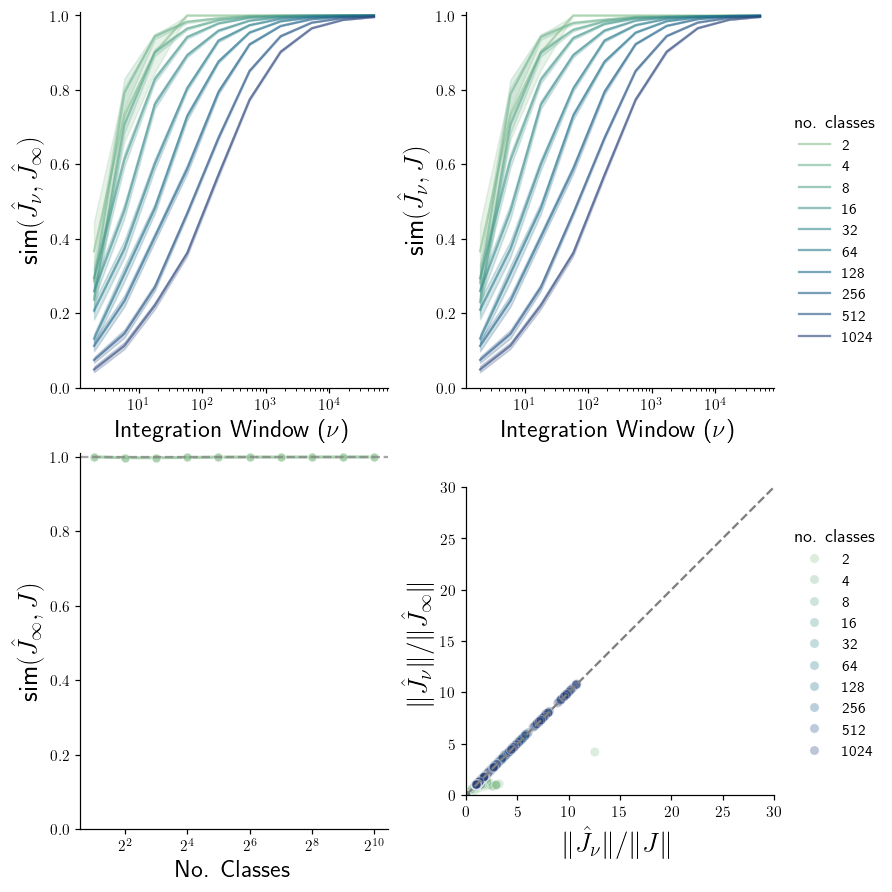

In [47]:
# plotting LOGISTIC NOISE
fig, ax = plt.subplots(2, 2, figsize=(8, 8), dpi=110, layout="constrained")

x = jnp.arange(0, 30, 0.1)
# for axs in ax.ravel():
#     axs.set_xscale("log", base=2)

flare_pal = sns.color_palette("flare", len(softmax_log_jac_data['num_classes'].unique()))
crest_pal = sns.color_palette("crest", len(softmax_log_jac_data['num_classes'].unique()))
cb_pal = sns.color_palette("colorblind", len(softmax_log_jac_data['num_classes'].unique()))

## z and q
sns.lineplot(data=softmax_log_jac_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0,0], palette=crest_pal)
ax[0, 0].set_xscale("log", base=10)
ax[0,0].set_ylabel(r"$\text{sim}(\hat{J}_\nu, \hat{J}_\infty)$", fontsize=18)
ax[0,0].legend().set_visible(False)

for axs in [ax[0,0], ax[0, 1]]:
    axs.set_xlabel(r"Integration Window ($\nu$)", fontsize=16)

## z and s
sns.lineplot(data=softmax_log_jac_data, x="int_window", y="cos_sim_z_s", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0,1], palette=crest_pal)
ax[0, 1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[0, 1].set_ylabel(r"$\text{sim}(\hat{J}_\nu, J)$", fontsize=18)
ax[0, 1].set_xscale("log", base=10)

## cosine sim q vs num classes
sns.lineplot(data=softmax_log_jac_data, x="num_classes", y="cos_sim_q_s", ax=ax[1, 0], alpha=0.7, color=crest_pal[0], lw=2, marker="o")
ax[1, 0].set_xscale("log", base=2)
ax[1, 0].axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
ax[1, 0].set_ylabel(r"$\text{sim}(\hat{J}_\infty, J)$", fontsize=18)
ax[1, 0].set_xlabel("No. Classes", fontsize=16)

for axs in [ax[0,0], ax[0,1], ax[1,0]]:
    axs.set_ylim(0.0, 1.01)

## norm comparison: z vs s
dd = softmax_log_jac_data.loc[softmax_log_jac_data["scale_factor"] == 1.0]
sns.scatterplot(data=dd, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=crest_pal, ax=ax[1, 1], alpha=0.3)
ax[1, 1].set_ylabel(r"$\lVert \hat{J}_\nu \rVert / \lVert \hat{J}_\infty \rVert$", fontsize=18)
ax[1, 1].set_xlabel(r"$\lVert \hat{J}_\nu \rVert / \lVert J \rVert$", fontsize=18)
ax[1, 1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[1, 1].plot(x, x, color="0.5", lw=1.5, ls="--")
# ax[1, 1].plot(x, x/5, color="0.5", lw=1.5, ls="-.")
ax[1, 1].set_aspect("equal")
ax[1, 1].set_xlim(0, 30)
ax[1, 1].set_ylim(0, 30)

sns.despine()


softmax_log_jac_fn = f"softmax_log_jac_mc_{today}.pdf"
# fig.savefig(os.path.join(FIGURES_PATH, softmax_log_jac_fn), transparent=True, dpi=300, bbox_inches="tight")

<>:25: SyntaxWarning: invalid escape sequence '\#'
<>:25: SyntaxWarning: invalid escape sequence '\#'
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_49439/2988265287.py:25: SyntaxWarning: invalid escape sequence '\#'
  axl_inset.set_xlabel("\# Classes", fontsize=14)


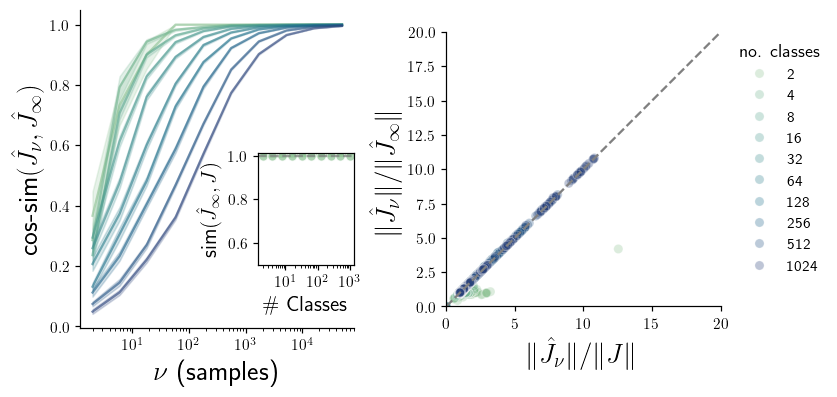

In [ ]:
# Logistic jacobian || modified figure
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.5), dpi=110, layout="constrained")

x = jnp.arange(0, 30, 0.1)
# for axs in ax.ravel():
#     axs.set_xscale("log", base=2)

flare_pal = sns.color_palette("flare", len(softmax_data['num_classes'].unique()))
crest_pal = sns.color_palette("crest", len(softmax_data['num_classes'].unique()))
cb_pal = sns.color_palette("colorblind", len(softmax_data['num_classes'].unique()))

## z and q (q vs s inset)
sns.lineplot(data=softmax_log_jac_data, x="int_window", y="cos_sim_z_q", hue="num_classes", lw=1.5, alpha=0.6, ax=ax[0], palette=crest_pal)
ax[0].set_xscale("log", base=10) 
ax[0].set_ylabel(r"$\text{cos-sim}(\hat{J}_\nu, \hat{J}_\infty)$", fontsize=18)
ax[0].legend().set_visible(False)
ax[0].set_xlabel(r"$\nu$ (samples)", fontsize=18)

# add the inset axis
axl_inset = ax[0].inset_axes([0.65, 0.2, 0.35, 0.35])
sns.lineplot(data=softmax_log_jac_data, x="num_classes", y="cos_sim_q_s", ax=axl_inset, alpha=0.7, color=crest_pal[0], lw=2, marker="o")
axl_inset.set_xscale("log", base=10)
axl_inset.axhline(y=1.0, color="0.5", alpha=0.7, lw=1.5, ls="--")
axl_inset.set_ylabel(r"$\text{sim}(\hat{J}_\infty, J)$", fontsize=14)
axl_inset.set_xlabel("\# Classes", fontsize=14)
axl_inset.set_ylim(0.5, 1.01)

## norm comparison: z vs s
df_c = softmax_log_jac_data.loc[softmax_log_jac_data['scale_factor'] == 1.0]
sns.scatterplot(data=df_c, x="norm_ratio_z_s", y="norm_ratio_z_q", hue="num_classes", palette=crest_pal, ax=ax[1], alpha=0.3)
ax[1].set_ylabel(r"$\lVert \hat{J}_\nu \rVert / \lVert \hat{J}_\infty \rVert$", fontsize=18)
ax[1].set_xlabel(r"$\lVert \hat{J}_\nu \rVert / \lVert J \rVert$", fontsize=18)
ax[1].legend(frameon=False, title="no. classes", title_fontsize=12, loc=(1.05, 0.1))
ax[1].plot(x, x, color="0.5", lw=1.5, ls="--")
# ax[1].plot(x, x/3, color="0.5", lw=1.5, ls="-.")
ax[1].set_aspect("equal")
ax[1].set_xlim(0, 20)
ax[1].set_ylim(0, 20)

sns.despine()

# softmax_log_jac_fn2 = f"softmax_log_jac_mc2_{today}.png"
# fig.savefig(os.path.join(FIGURES_PATH, softmax_log_jac_fn2), transparent=True, dpi=300, bbox_inches="tight")

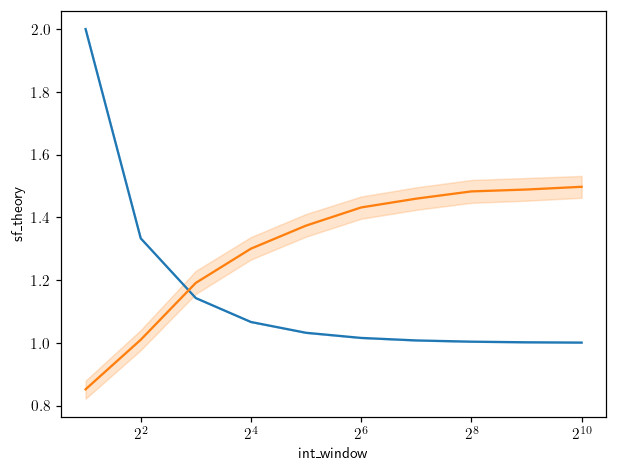

In [118]:
fig, ax = plt.subplots(dpi=110)
sns.lineplot(data=softmax_jac_data, x="int_window", y="sf_theory")
sns.lineplot(data=softmax_jac_data, x="int_window", y="sf_opt")

ax.set_xscale("log", base=2)

In [120]:
(2, 3) + (1, )

(2, 3, 1)